# IT6119 – Final Project
## Analyse av helsedata og enkel KI-modell

Denne notebooken viser en enkel arbeidsflyt for datakvalitet, visualisering og modellering.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

## 1. Last inn datasettet

In [9]:
df = pd.read_csv('synthetic_dataset.csv')
df.head()

,patient_id,age,sex,medication_name,dose_mg,days_since_start,muscle_pain_score,fatigue_score,headache_score,gi_symptoms_score,sleep_disturbance_score,overall_side_effect_score,adherence_status,adherence_assessment_date
0,1,57,F,Ezetrol,10,42,2,1,1,1,1,2,0,2026-03-12
1,2,63,M,Ezetrol,10,88,3,2,2,1,2,3,0,2026-04-01
2,3,49,F,Ezetrol,10,15,1,1,1,1,1,1,0,2026-02-27
3,4,72,M,Ezetrol,10,120,4,3,2,2,3,4,1,2026-05-03
4,5,54,F,Ezetrol,10,33,2,2,1,1,1,2,0,2026-03-18


## 2. Datakvalitet

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   patient_id                 500 non-null    int64
 1   age                        500 non-null    int64
 2   sex                        500 non-null    str  
 3   medication_name            500 non-null    str  
 4   dose_mg                    500 non-null    int64
 5   days_since_start           500 non-null    int64
 6   muscle_pain_score          500 non-null    int64
 7   fatigue_score              500 non-null    int64
 8   headache_score             500 non-null    int64
 9   gi_symptoms_score          500 non-null    int64
 10  sleep_disturbance_score    500 non-null    int64
 11  overall_side_effect_score  500 non-null    int64
 12  adherence_status           500 non-null    int64
 13  adherence_assessment_date  500 non-null    str  
dtypes: int64(11), str(3)
memory usage: 63

In [11]:
df.describe()

,patient_id,age,dose_mg,days_since_start,muscle_pain_score,fatigue_score,headache_score,gi_symptoms_score,sleep_disturbance_score,overall_side_effect_score,adherence_status
count,500.000000,500.000000,500.0,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000,500.000000
mean,250.500000,58.932000,10.0,73.034000,2.500000,2.410000,1.87000,1.704000,1.872000,2.500000,0.250000
std,144.481833,8.826732,0.0,40.548653,1.119154,1.077135,0.78123,0.788433,0.782842,1.119154,0.433446
min,1.000000,44.000000,10.0,15.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,0.000000
25%,125.750000,50.750000,10.0,32.750000,1.750000,1.000000,1.00000,1.000000,1.000000,1.750000,0.000000
50%,250.500000,58.000000,10.0,64.000000,2.500000,2.000000,2.00000,1.000000,2.000000,2.500000,0.000000
75%,375.250000,67.000000,10.0,101.000000,3.250000,3.000000,2.00000,2.000000,2.250000,3.250000,0.250000
max,500.000000,74.000000,10.0,148.000000,4.000000,4.000000,3.00000,3.000000,3.000000,4.000000,1.000000


## 3. Visualiseringer

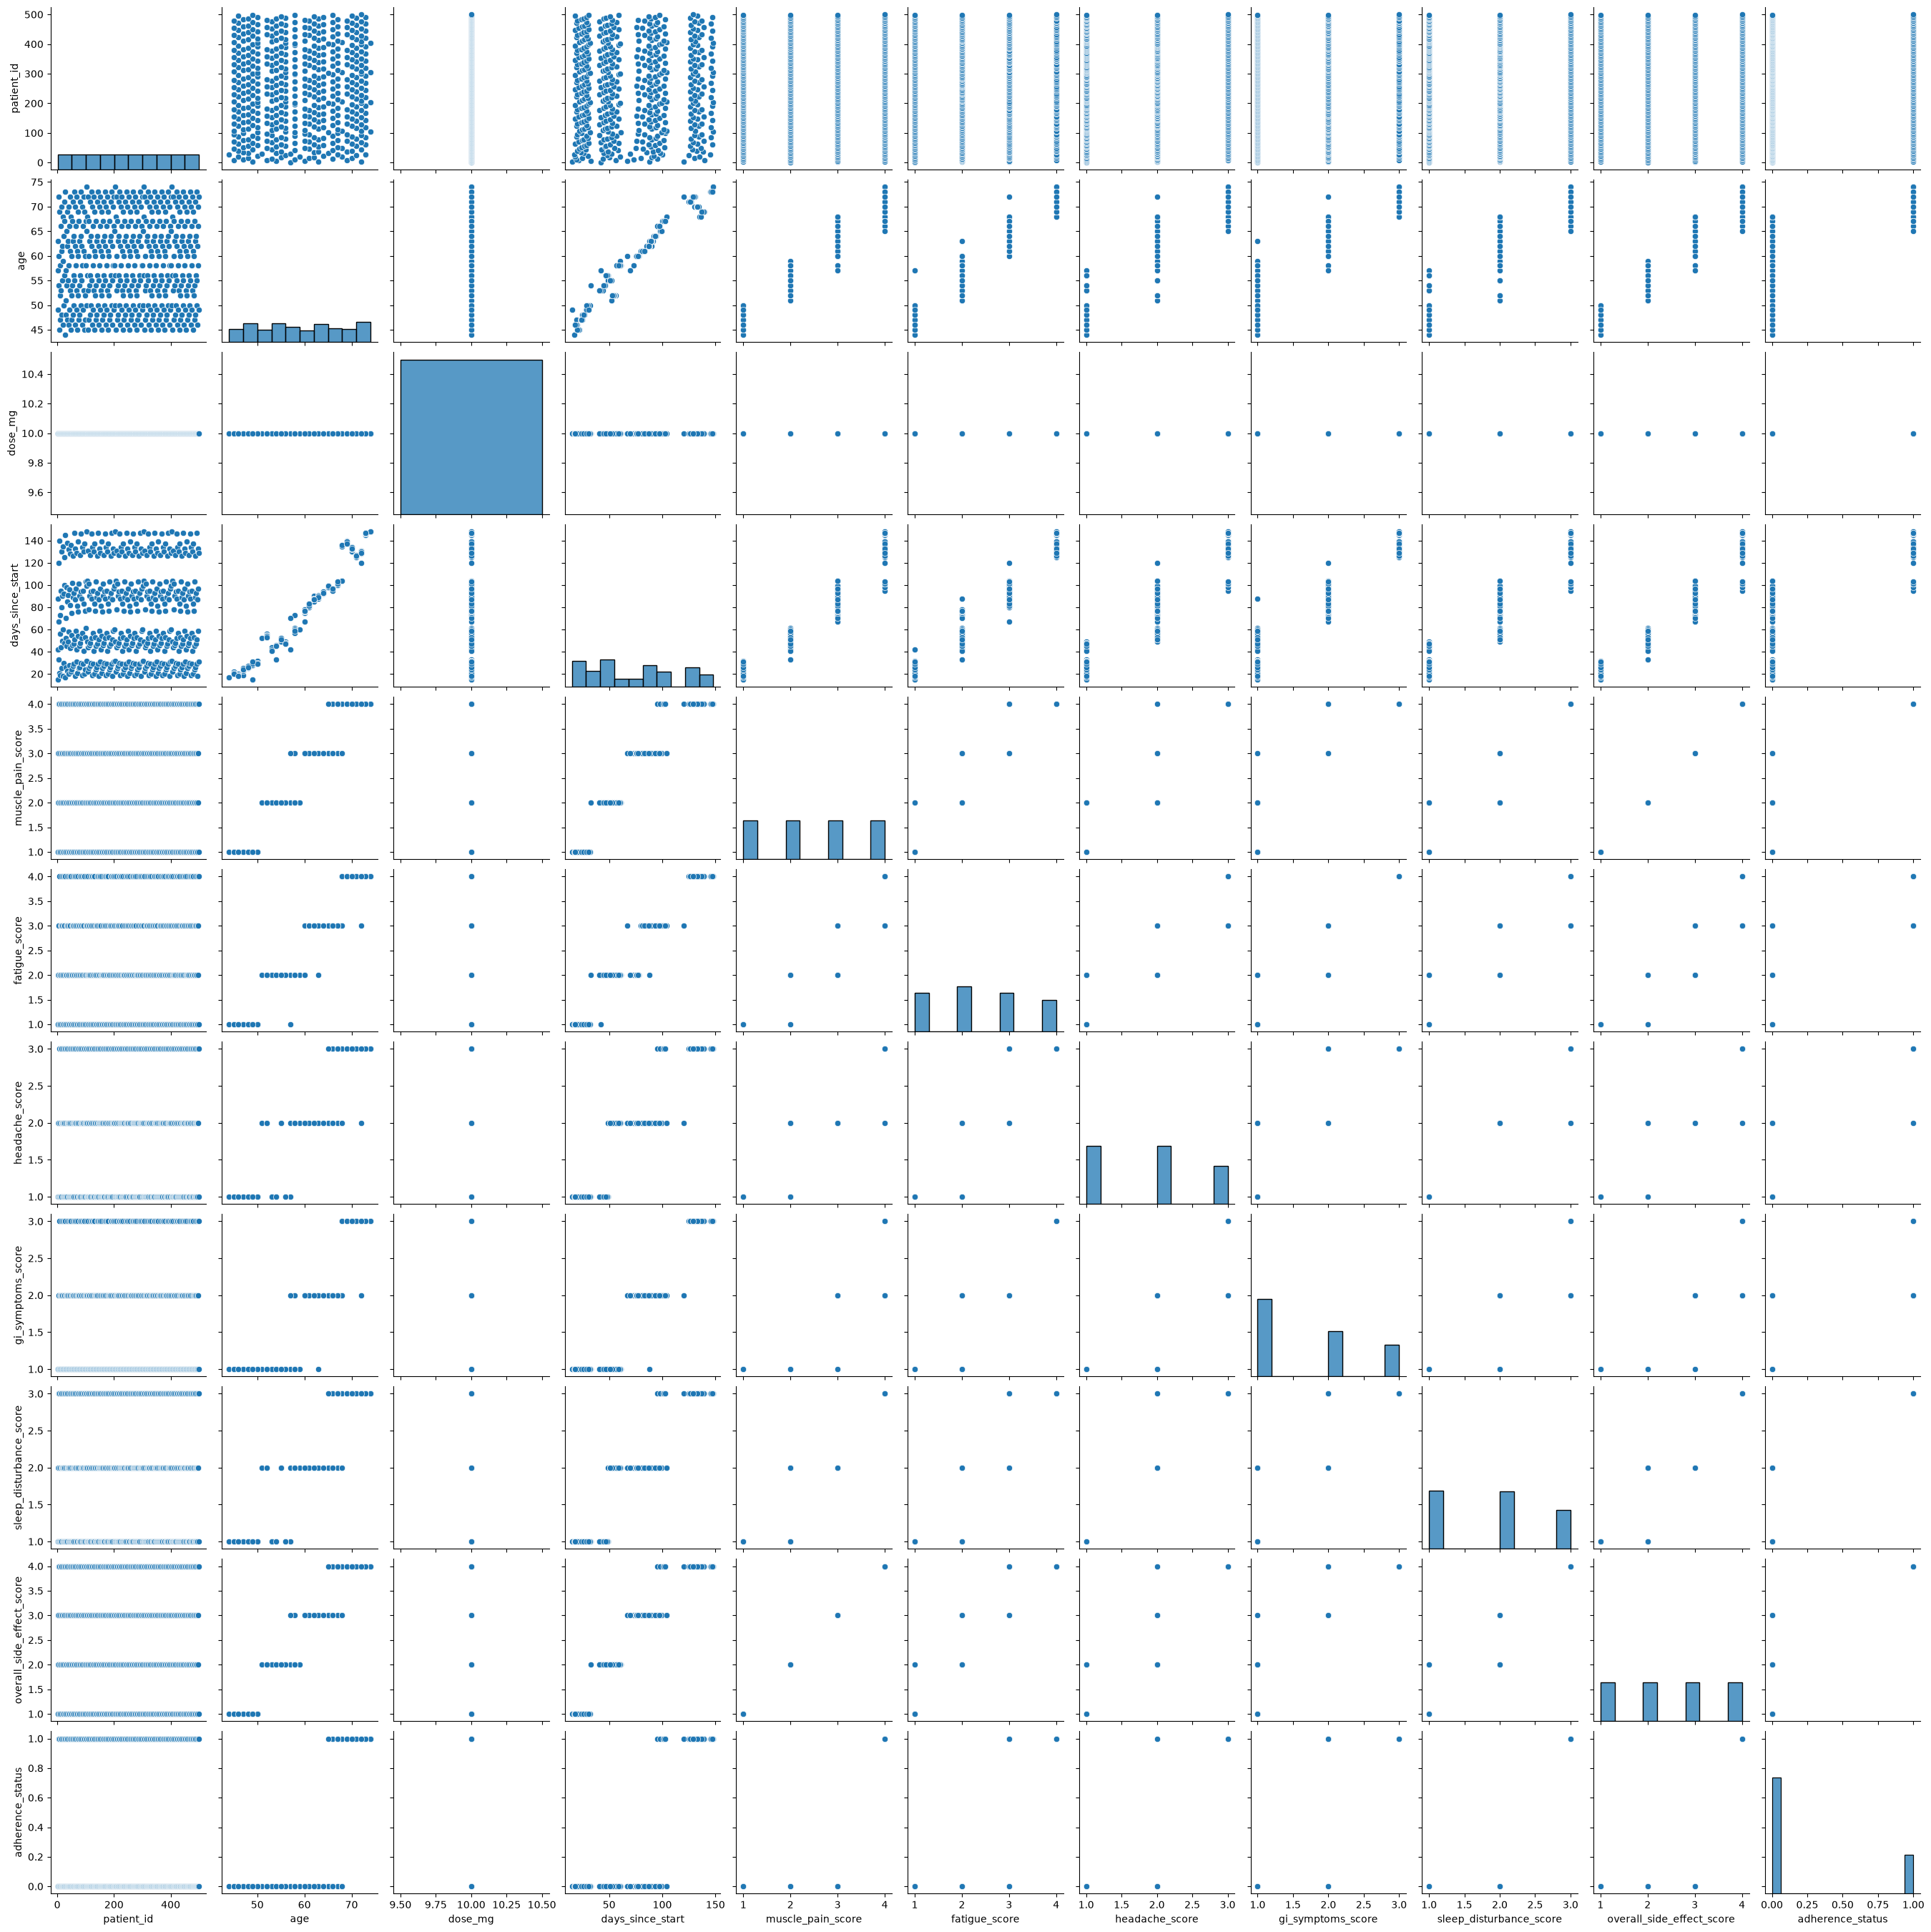

In [12]:
sns.pairplot(df)
plt.show()

## 4. Modellering – Logistisk regresjon

In [ ]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)
accuracy_score(y_test, y_pred)

### Confusion matrix

In [ ]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.show()

## 5. Modellering – Random Forest

In [ ]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
accuracy_score(y_test, y_pred_rf)

## 6. Refleksjon

- Datasettet er syntetisk og trygt å bruke.
- Logistisk regresjon gir en enkel baseline-modell.
- Random Forest gir ofte bedre resultater, men er mindre transparent.
- KI i helsetjenesten må brukes med fokus på datakvalitet, transparens og risiko.
- Modellen her er kun et læringsverktøy og ikke egnet for klinisk bruk.